In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install numpy
!pip install matplotlib
!pip install os

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import os

In [ ]:
def cleanup_files(directory, days_old=30):
    """
    Deletes files older than the specified number of days in the given directory.
    """
    cutoff_date = datetime.now() - timedelta(days=days_old)
    old_files = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            file_modified_date = datetime.fromtimestamp(os.path.getmtime(file_path))
            
            if file_modified_date < cutoff_date:
                old_files.append(file_path)

    if old_files:
        for file_path in old_files:
            try:
                os.remove(file_path)
                print(f"Deleted: {file_path}")
            except Exception as e:
                print(f"Error deleting {file_path}: {e}")
    else:
        print("No old files found to delete.")


In [3]:
# Example historical data with actual dates
data = {
    "date": ["2024-11-11", "2024-11-12", "2024-11-13", "2024-11-14", "2024-11-15"],
    "used_space": [70, 72, 75, 78, 80]  # Replace with actual usage
}
df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"])  # Convert to datetime
df["day_number"] = (df["date"] - df["date"].min()).dt.days + 1  # Day number from the start

# Train the model
X = df[["day_number"]]
y = df["used_space"]

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [4]:
# Predict future usage
future_days = 10  # Predict for the next 10 days
future_dates = [df["date"].max() + timedelta(days=i) for i in range(1, future_days + 1)]
future_day_numbers = [(date - df["date"].min()).days + 1 for date in future_dates]

future_X = np.array(future_day_numbers).reshape(-1, 1)
predictions = model.predict(future_X)
# Debugging output
print(f"Future Day Numbers: {future_day_numbers}")
print(f"Predictions: {predictions}")

Future Day Numbers: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Predictions: [ 82.8  85.4  88.   90.6  93.2  95.8  98.4 101.  103.6 106.2]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
# Display predictions
predicted_data = pd.DataFrame({
    "date": future_dates,
    "predicted_used_space": predictions
})

print("Predicted Disk Usage:")
print(predicted_data)

Predicted Disk Usage:
        date  predicted_used_space
0 2024-11-16                  82.8
1 2024-11-17                  85.4
2 2024-11-18                  88.0
3 2024-11-19                  90.6
4 2024-11-20                  93.2
5 2024-11-21                  95.8
6 2024-11-22                  98.4
7 2024-11-23                 101.0
8 2024-11-24                 103.6
9 2024-11-25                 106.2


In [ ]:
# Set threshold (e.g., 85%)
threshold = 85
threshold_exceed = predicted_data[predicted_data["predicted_used_space"] >= threshold]

if not threshold_exceed.empty:
    print(f"Disk space is predicted to exceed {threshold}% on:")
    print(threshold_exceed)
    # Trigger Cleanup Function if Prediction Exceeds Threshold
    # Assuming a cleanup function that deletes old files
    cleanup_files("/var/log", days_old=30)
else:
    print("Disk space usage is within acceptable limits.")



Disk space will exceed 85% on:
        date  predicted_used_space
1 2024-11-17                  85.4
2 2024-11-18                  88.0
3 2024-11-19                  90.6
4 2024-11-20                  93.2
5 2024-11-21                  95.8
6 2024-11-22                  98.4
7 2024-11-23                 101.0
8 2024-11-24                 103.6
9 2024-11-25                 106.2


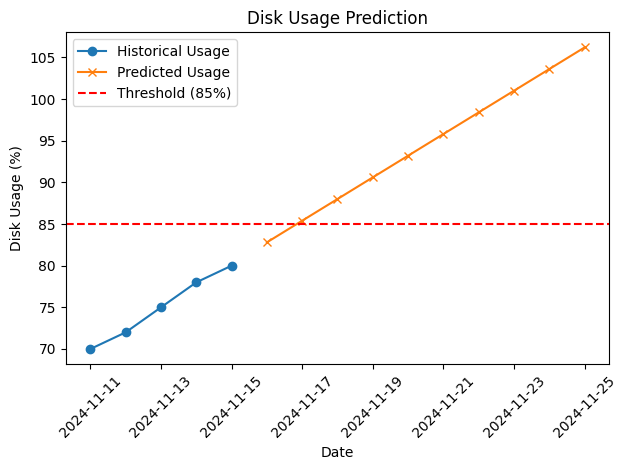

In [6]:
# Plot results
plt.plot(df["date"], df["used_space"], label="Historical Usage", marker="o")
plt.plot(predicted_data["date"], predicted_data["predicted_used_space"], label="Predicted Usage", marker="x")
plt.axhline(y=threshold, color="r", linestyle="--", label=f"Threshold ({threshold}%)")
plt.xlabel("Date")
plt.ylabel("Disk Usage (%)")
plt.legend()
plt.title("Disk Usage Prediction")
plt.xticks(rotation=45)
plt.tight_layout()

# Ensure plot displays
plt.show()